<a href="https://colab.research.google.com/github/SampMark/Deep-Learning/blob/main/Deep_Q_Network_DQN_using_Keras_and_OpenAI_Gymnasium_in_CartPole_v1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Implementação do algoritmo Deep Q-Network (DQN), usando Keras e OpenAI Gymnasium, para o ambiente CartPole-v1**


### **Visão Geral do Aprendizado por Reforço (RL)**

A Aprendizagem por Reforço (RL) é um ramo fascinante do aprendizado de máquina que se inspira no comportamento humano e animal.
Em vez de aprender a partir de um conjunto de dados rotulado (como na aprendizagem supervisionada) ou encontrar padrões em dados não rotulados (como na aprendizagem não supervisionada). É um novo paradigma no aprendizado de máquina em que um **agente** aprende a tomar decisões interagindo com um **ambiente**. Através de tentativa e erro, o agente descobre qual ação maximiza uma **recompensa cumulativa** ao longo do tempo.

### **Diferenças em relação ao Aprendizado Supervisionado**
* **Feedback Não Determinístico**: Diferentemente do aprendizado supervisionado, onde labels são conhecidos, no RL as recompensas são **incertas** e dependem da sequência de ações.  
  * Por exemplo, um modelo de classificação detecta imediatamente se uma previsão está certa ou errada, mas um agente de RL só descobre a eficácia de uma ação após múltiplos passos.

* **Ambiente Dinâmico**: o estado do ambiente muda constantemente como resultado das ações do agente, tornando o problema **não estacionário**

### **Componentes Chave da RL**

1.  O **agente** (_agent_) é a entidade que aprende e toma decisões. Pode ser um robô navegando em um labirinto, um programa jogando xadrez, um sistema controlando uma usina de energia, um programa que decide onde colocar anúncios em uma página da web.
2.  O **ambiente** (_environment_) é o mundo com o qual o agente interage, em que ela não tem controle total sobre o ambiente (um labirinto, um tabuleiro de xadrez, uma página da web).
3.  O **estado** ($s$) é uma representação da situação atual do ambiente. Pode ser a posição do robô, a configuração das peças no tabuleiro ou os sensores da usina.
4.  A **ação ($a$):** é uma das possíveis escolhas que o agente pode fazer em um determinado estado. Tais como mover o robô para frente, mover uma peça específica, ajustar uma válvula.
5.  A **recompensa** ($r$) é um sinal numérico que o ambiente envia ao agente após cada ação. Indicando quão boa (ou ruim) foi a ação tomada em relação ao objetivo. Recompensas podem ser imediatas ou atrasadas. Por exemplo, em um jogo, a recompensa final de "ganhar" só vem após muitas ações.
6.  A **política** ($\pi$) é a estratégia que o agente usa para decidir qual ação tomar em cada estado. Pode ser determinística (sempre a mesma ação para um estado) ou estocástica (uma distribuição de probabilidade sobre as ações). O objetivo do aprendizado por reforço é encontrar uma "política ótima" ($\pi^*$) que maximize a recompensa cumulativa esperada.
7.  **Função de Valor ($V(s)$ ou $Q(s,a)$):**
    * **$V(s)$ (Função de Valor do Estado)**: estima a recompensa cumulativa esperada a partir de um estado $s$, seguindo uma determinada política.
    * **$Q(s,a)$ (Função de Valor da Ação-Estado)**: estima a recompensa cumulativa esperada ao tomar uma ação $a$ no estado $s$ e, subsequentemente, seguir uma determinada política, sendo crucial em algoritmos como o _Q-Learning_.

### **O Processo de Aprendizagem**

* **Interação Agente-Ambiente**: o agente executa uma ação no ambiente, que por sua vez atualiza seu **estado** e retorna uma recompensa. Esse ciclo é repetido dinamicamente:

  ```
  Agente → Ação → Ambiente → Novo Estado + Recompensa → Agente (atualiza estratégia)
  ```
Em outras palavras, o agente interage com o ambiente em uma sequência de passos de tempo discretos:
1.  O agente observa o estado atual $s_t$ do ambiente.
2.  Com base no estado $s_t$, o agente escolhe uma ação $a_t$ de acordo com sua política $\pi$.
3.  O ambiente transita para um novo estado $s_{t+1}$ e retorna uma recompensa $r_{t+1}$ ao agente.
4.  O agente usa essa informação (a transição $(s_t, a_t, r_{t+1}, s_{t+1})$) para atualizar sua política e/ou sua função de valor, aprendendo com a experiência.

### **O Dilema Exploração _vs._ Explotação**

Um desafio central em RL é o equilíbrio entre **exploração** (tentar novas ações para descobrir quais recompensas elas trazem) e **explotação** (usar o conhecimento atual para tomar as ações que se acredita serem as melhores). Muita exploração significa que o agente nunca utiliza o que aprendeu, enquanto muita explotação pode fazer com que o agente fique preso em uma solução subótima, sem nunca descobrir ações melhores.

---

### **Q-Learning Tradicional vs. DQN**

No Q-Learning tradicional, mantemos uma tabela (_Q-table_) com valores $Q(s,a)$ para cada par estado-ação possível. O aprendizado ocorre atualizando esses valores usando a equação de Bellman:

$$Q(s,a) \leftarrow Q(s,a) + \alpha [R + \gamma \max_{a'} Q(s',a') - Q(s,a)]$$

Onde:
* $\alpha$ é a taxa de aprendizado.
* $\gamma$ é o fator de desconto para recompensas futuras.
* $R$ é a recompensa imediata.
* $s'$ é o próximo estado.
* $\max_{a'} Q(s',a')$ é o máximo valor Q esperado no próximo estado.

O problema é que, para ambientes com muitos estados (como imagens) ou estados contínuos (como no CartPole), uma Q-table se torna inviável.

Entretanto, o DQN resolve esse obstáculo usando uma **rede neural profunda**, geralmente uma _Multi-Layer Perceptron_ para estados vetoriais como o do _CartPole_ (ambiente), ou uma Rede Neural Convolucional para entradas de imagem, no intuito de *aproximar* a função Q-valor, $Q(s,a; \theta) \approx Q^*(s,a)$, onde $\theta$ são os pesos da rede neural.

---


In [8]:
# Exibir informações da GPU
!nvidia-smi

Tue May 13 19:05:51 2025       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 550.54.15              Driver Version: 550.54.15      CUDA Version: 12.4     |
|-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   39C    P8              9W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

## **Deep Q-Network (DQN) para CartPole-v1 com Keras e Gymnasium**

O código a seguir é uma implementação do algoritmo **Deep Q-Network (DQN)**, uma abordagem bastante difundida e poderosa na aprendizagem por reforço, que combina o _Q-Learning_ tradicional com redes neurais profundas para lidar com espaços de estados complexos ou contínuos, onde uma tabela Q simples seria impraticável.

O **Gymnasium** (`gymnasium`), é o sucessor do `gym` da OpenAI, uma biblioteca padrão para desenvolver e comparar algoritmos de RL.

A DQN treina um agente para resolver o problema CartPole-v1, usando uma rede neural (Keras) para estimar os valores $Q$ de tomar certas ações em certos estados.

Duas técnicas chave são empregadas para estabilidade e eficiência:

1. **Replay de experiências** para armazenar transições e amostrá-las aleatoriamente para treinar a rede, o que quebra correlações e reutiliza dados.
2. **Rede Alvo** (_Target Network_), usa uma rede separada com pesos atualizados periodicamente para calcular os Q-valores alvo, o que evita que os alvos mudem a cada passo de gradiente da rede principal, estabilizando o aprendizado.

A estratégia $\epsilon$-greedy garante que o agente explore o ambiente no início e gradualmente explore o conhecimento adquirido para tomar decisões ótimas. O objetivo é que, após o treinamento, o modelo Keras aprenda uma função Q que permita ao agente manter o poste equilibrado pelo maior tempo possível.




## **Sobre o ambiente CartPole-v1**

O **CartPole-v1** é um ambiente clássico de controle. O objetivo é equilibrar um poste vertical em cima de um carrinho que pode se mover para a esquerda ou para a direita.

  * **Estado**: a observação do ambiente é um vetor de 4 números:
        1.  Posição do carrinho
        2.  Velocidade do carrinho
        3.  Ângulo do poste (em relação à vertical)
        4.  Velocidade na ponta do poste
  * **Ações**: o agente pode tomar duas ações discretas:
        1.  Empurrar o carrinho para a esquerda.
        2.  Empurrar o carrinho para a direita.
  * **Recompensa**: o agente recebe uma recompensa de +1 para cada passo de tempo em que o poste permanece equilibrado (dentro de certos limites de ângulo e posição do carrinho).
  * **Término do Episódio**: um episódio termina se o poste cair além de um certo ângulo, se o carrinho sair dos limites da tela, ou se um número máximo de passos for atingido (geralmente 200 ou 500 para versões "resolvidas").

  * **Visualização**: https://youtu.be/YB9S74k3yhc?si=z15ZpQCTbUoA7JsD


In [11]:
# Instalação das dependências
!pip install gymnasium

In [9]:
!pip install tensorflow

  Using cached numpy-2.0.2-cp311-cp311-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (60 kB)
Using cached numpy-2.0.2-cp311-cp311-manylinux_2_17_x86_64.manylinux2014_x86_64.whl (19.5 MB)
  Attempting uninstall: numpy
    Found existing installation: numpy 2.2.5
    Uninstalling numpy-2.2.5:
      Successfully uninstalled numpy-2.2.5
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
dopamine-rl 4.1.2 requires gym<=0.25.2, but you have gym 0.26.2 which is incompatible.


In [10]:
!pip install --upgrade gym

In [12]:
!pip install --upgrade numpy

  Using cached numpy-2.2.5-cp311-cp311-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (62 kB)
Using cached numpy-2.2.5-cp311-cp311-manylinux_2_17_x86_64.manylinux2014_x86_64.whl (16.4 MB)
  Attempting uninstall: numpy
    Found existing installation: numpy 2.0.2
    Uninstalling numpy-2.0.2:
      Successfully uninstalled numpy-2.0.2
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
numba 0.60.0 requires numpy<2.1,>=1.22, but you have numpy 2.2.5 which is incompatible.
dopamine-rl 4.1.2 requires gym<=0.25.2, but you have gym 0.26.2 which is incompatible.
tensorflow 2.18.0 requires numpy<2.1.0,>=1.26.0, but you have numpy 2.2.5 which is incompatible.


In [3]:
# -*- coding: utf-8 -*-
# --- Importações necessárias ---
import gymnasium as gym # Usando Gymnasium (sucessor do Gym)
import numpy as np
import random
import tensorflow as tf
from collections import deque
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Input
from tensorflow.keras.optimizers import Adam
import matplotlib.pyplot as plt

In [5]:
# --- Configurações Globais e Hiperparâmetros ---
RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)
random.seed(RANDOM_SEED)
tf.random.set_seed(RANDOM_SEED)

# Hiperparâmetros do DQN
STATE_SIZE = None # Será definido pelo ambiente
ACTION_SIZE = None # Será definido pelo ambiente
LEARNING_RATE = 0.001
GAMMA = 0.95  # Fator de desconto
MEMORY_SIZE = 2000
BATCH_SIZE = 64

# Parâmetros de Exploração (Epsilon-Greedy)
EPSILON_INITIAL = 1.0
EPSILON_MIN = 0.01
EPSILON_DECAY = 0.995 # Decaimento um pouco mais lento para mais exploração inicial

# Parâmetros de Treinamento
EPISODES = 500 # Aumentado para permitir aprendizado
MAX_STEPS_PER_EPISODE = 200 # Limite padrão para CartPole-v1 resolvido
TARGET_UPDATE_FREQUENCY = 10 # Frequência de atualização da rede alvo (em episódios)

## 1.  **Classe DQNAgent**

* **Função `__init__(self, state_size, action_size)`**:

  * Inicializa os hiperparâmetros (taxa de aprendizado, gama, tamanho da memória, epsilon inicial).
  * Cria duas redes neurais com a mesma arquitetura usando `_build_model()`:
    * `self.model`: rede principal (ou online) que é treinada a cada passo de aprendizado, seus pesos $\theta$ são atualizados frequentemente.
    * `self.target_model`: rede alvo, em que os pesos $\theta^-$ são uma cópia dos pesos da rede principal, mas são atualizados com menos frequência (a cada `TARGET_UPDATE_FREQUENCY` episódios no código).
    * O uso de uma rede alvo ajuda a estabilizar o treinamento, pois os alvos para a equação de Bellman não mudam a cada pequena atualização da rede principal.
    * Inicializa `self.memory` como um `deque`, que é um buffer de replay de experiências.

* **Função `_build_model(self)`**:
  * Define a arquitetura da rede neural usando `tensorflow.keras.Sequential`.
    * **Entrada**: `Input(shape=(self.state_size,))` - corresponde às 4 observações do CartPole.
    * **Camadas Ocultas**: duas camadas `Dense` com 24 neurônios cada e ativação 'relu' que aprendem representações intermediárias do estado.
    * **Camada de Saída*:* `Dense(self.action_size, activation='linear')` - produz um valor Q para cada ação possível (2 no CartPole). A ativação 'linear' é usada porque os Q-valores podem ser quaisquer números reais.
    * A **compilação** utiliza otimizador `Adam` e a função de perda 'mse' (Mean Squared Error).
    * O objetivo do treinamento é minimizar a diferença entre os Q-valores previstos e os Q-valores alvo calculados pela equação de Bellman.

* **Função `update_target_model(self)`**: copia os pesos de `self.model` para `self.target_model`.

* **Função `remember(self, state, action, reward, next_state, done)`**: armazena a tupla de transição $(s, a, r, s', \text{done})$ no buffer de memória `self.memory`.
  * **`act(self, state)`**: implementa a política $\epsilon$-greedy:
    * Com probabilidade `self.epsilon`, escolhe uma ação aleatória (exploração).
    * Caso contrário (com probabilidade $1 - \text{self.epsilon}$), usa `self.model.predict(state)` para obter os Q-valores para todas as ações no estado atual e escolhe a ação com o maior Q-valor (`np.argmax`) (explotação).
* **Função `replay(self)`**: esta é a etapa central do aprendizado:
  * Se a memória não tiver amostras suficientes (`BATCH_SIZE`), não faz nada.
  * Seleciona aleatoriamente um `minibatch` de experiências do `self.memory` para amostrar aleatoriamente a quebra de correlações temporais entre as experiências, tornando o treinamento mais estável e eficiente.
  * Para cada experiência $(s, a, r, s', \text{done})$ no minibatch:
    * Calcula o **Q-valor alvo ($y_j$)**:
    * Se o próximo estado $s'$ for terminal (`done` é True), o alvo é apenas a recompensa $r$.
    * Caso contrário, o alvo é $r + \gamma \max_{a'} Q_{\text{target}}(s', a'; \theta^-)$. Note que $\max_{a'} Q_{\text{target}}(s', a'; \theta^-)$ é obtido da `self.target_model.predict(next_states)`, usando os pesos da rede alvo ($\theta^-$) para maior estabilidade.
    * Os Q-valores atuais para o estado $s$ são obtidos de `self.model.predict(states)`. Uma cópia é feita (`q_target_for_training`).
    * Apenas o Q-valor da ação $a$ que foi efetivamente tomada é atualizado com o $y_j$ calculado. Os Q-valores das outras ações permanecem os mesmos para este passo de treinamento.
    * Treina a rede principal: `self.model.fit(states, q_target_for_training, epochs=1, verbose=0)`. A rede aprende a mapear os `states` para os `q_target_for_training` calculados, minimizando o erro quadrático médio.
    * Decai o `self.epsilon` para reduzir gradualmente a exploração ao longo do tempo.

In [6]:
class DQNAgent:
    """
    Agente Deep Q-Network.
    """
    def __init__(self, state_size, action_size):
        self.state_size = state_size
        self.action_size = action_size
        self.memory = deque(maxlen=MEMORY_SIZE)
        self.epsilon = EPSILON_INITIAL

        # Modelo principal (treinado a cada passo de replay)
        self.model = self._build_model()
        # Modelo alvo (usado para calcular os valores Q alvo)
        self.target_model = self._build_model()
        self.update_target_model() # Sincroniza os pesos inicialmente

    def _build_model(self):
        """Constrói a rede neural para o Q-Learning."""
        model = Sequential([
            Input(shape=(self.state_size,)),
            Dense(24, activation='relu', name='dense_1'),
            Dense(24, activation='relu', name='dense_2'),
            Dense(self.action_size, activation='linear', name='output_q_values')
        ])
        model.compile(loss='mse', optimizer=Adam(learning_rate=LEARNING_RATE))
        return model

    def update_target_model(self):
        """Copia os pesos do modelo principal para o modelo alvo."""
        self.target_model.set_weights(self.model.get_weights())
        print("Pesos da Target Network atualizados.")

    def remember(self, state, action, reward, next_state, done):
        """Armazena a experiência no buffer de memória."""
        self.memory.append((state, action, reward, next_state, done))

    def act(self, state):
        """Escolhe uma ação usando a política epsilon-greedy."""
        if np.random.rand() <= self.epsilon:
            return random.randrange(self.action_size) # Exploração
        # Explotação: escolhe a ação com o maior Q-valor previsto
        act_values = self.model.predict(state, verbose=0)
        return np.argmax(act_values[0])

    def replay(self):
        """Treina o modelo principal usando um minibatch de experiências."""
        if len(self.memory) < BATCH_SIZE:
            return # Não treina se não houver memória suficiente

        minibatch = random.sample(self.memory, BATCH_SIZE)

        states = np.vstack([experience[0] for experience in minibatch])
        actions = np.array([experience[1] for experience in minibatch])
        rewards = np.array([experience[2] for experience in minibatch])
        next_states = np.vstack([experience[3] for experience in minibatch])
        dones = np.array([experience[4] for experience in minibatch])

        # Calcula os Q-valores alvo usando a target network
        # Q(s', a') são previstos pela target_model para maior estabilidade
        q_next_values_target_model = self.target_model.predict(next_states, verbose=0)

        # Os Q-valores atuais são previstos pelo modelo principal (serão os alvos)
        q_current_values_main_model = self.model.predict(states, verbose=0)
        q_target_for_training = np.copy(q_current_values_main_model)


        for i in range(BATCH_SIZE):
            if dones[i]:
                q_target_for_training[i, actions[i]] = rewards[i]
            else:
                # Bellman equation: Q_target = R + gamma * max_a'(Q_target_model(s', a'))
                q_target_for_training[i, actions[i]] = rewards[i] + GAMMA * np.amax(q_next_values_target_model[i])

        # Treina o modelo principal
        self.model.fit(states, q_target_for_training, epochs=1, verbose=0)

        # Decaimento do Epsilon
        if self.epsilon > EPSILON_MIN:
            self.epsilon *= EPSILON_DECAY

# 2.  **Função train_agent()**

* Cria o ambiente `CartPole-v1`.
* Obtém `STATE_SIZE` e `ACTION_SIZE` do ambiente.
* Instancia o `DQNAgent`.
* **Loop principal** de treinamento por `EPISODES`:
  * Reseta o ambiente para obter o estado inicial.
  * **Loop interno** por `MAX_STEPS_PER_EPISODE`:
    * O agente escolhe uma ação `action` usando `agent.act(state)`.
    * A ação é executada no ambiente, resultando em `next_state`, `reward`, `terminated`, `truncated`.
    * A recompensa é modificada se o episódio termina (`done`), uma penalidade de -10 é aplicada - uma heurística para incentivar o agente a sobreviver por mais tempo.
    * A transição é armazenada na memória com `agent.remember()`.
    * O estado atual é atualizado para `next_state`.
    * Se o episódio terminar, o loop de passos é interrompido.
* Ao final de cada episódio, `agent.replay()` é chamado para treinar a rede.
* Scores (duração do episódio) e valores de epsilon são registrados.
* E a rede alvo é atualizada periodicamente.

In [7]:
def train_agent():
    """Função principal para treinar o agente DQN."""
    # Usar render_mode="rgb_array" para capturar frames para um vídeo depois, ou None para treino mais rápido
    env = gym.make('CartPole-v1') # Ou 'CartPole-v1', render_mode="human" para ver em tempo real

    global STATE_SIZE, ACTION_SIZE
    STATE_SIZE = env.observation_space.shape[0]
    ACTION_SIZE = env.action_space.n

    # Configurar sementes do ambiente para reprodutibilidade
    env.reset(seed=RANDOM_SEED)
    env.action_space.seed(RANDOM_SEED)

    agent = DQNAgent(STATE_SIZE, ACTION_SIZE)
    scores = [] # Lista para armazenar os scores de cada episódio
    epsilon_values = [] # Lista para armazenar o epsilon a cada episódio

    print(f"Iniciando treinamento com DQN para CartPole-v1...")
    print(f"State size: {STATE_SIZE}, Action size: {ACTION_SIZE}")
    print(f"Modelo DQN:\n{agent.model.summary()}")

    for e in range(EPISODES):
        state, info = env.reset()
        state = np.reshape(state, [1, STATE_SIZE])
        total_reward = 0

        for step in range(MAX_STEPS_PER_EPISODE):
            action = agent.act(state)
            next_state, reward, terminated, truncated, _ = env.step(action)
            done = terminated or truncated

            # Modificação da recompensa para incentivar a sobrevivência
            reward = reward if not done else -10

            next_state = np.reshape(next_state, [1, STATE_SIZE])
            agent.remember(state, action, reward, next_state, done)
            state = next_state
            total_reward += reward # No CartPole, reward é +1 para cada passo que o poste não caiu

            if done:
                break # Sai do loop de passos se o episódio terminou

        agent.replay() # Treina o agente ao final de cada episódio

        scores.append(step + 1) # Score é o número de passos que o poste ficou em pé
        epsilon_values.append(agent.epsilon)

        print(f"Episódio: {e+1}/{EPISODES}, Score: {step+1}, Epsilon: {agent.epsilon:.4f}, Memória: {len(agent.memory)}")

        # Atualiza a rede alvo periodicamente
        if (e + 1) % TARGET_UPDATE_FREQUENCY == 0:
            agent.update_target_model()

        # Critério de "resolvido" para CartPole-v1 (média de scores > 195 por 100 episódios)
        # Para este exemplo didático, vamos apenas rodar os EPISODES definidos.
        # Pode-se adicionar uma verificação aqui se desejar.

    env.close()
    print("Treinamento Concluído!")
    return agent, scores, epsilon_values

## 3.  **Funções plot_training_results() e evaluate_agent()**
    
São usadas para visualizar o progresso do treinamento (_scores_ e epsilon) e para ver o agente treinado em ação, usando apenas explotação e renderizando o ambiente.

In [8]:
def plot_training_results(scores, epsilon_values):
    """Plota os resultados do treinamento."""
    fig, ax1 = plt.subplots(figsize=(12, 6))

    color = 'tab:red'
    ax1.set_xlabel('Episódio')
    ax1.set_ylabel('Score (Duração)', color=color)
    ax1.plot(scores, color=color)
    ax1.tick_params(axis='y', labelcolor=color)
    # Linha de score médio móvel para visualizar tendência
    moving_avg = np.convolve(scores, np.ones(100)/100, mode='valid') # Média móvel de 100 episódios
    ax1.plot(np.arange(len(moving_avg)) + 99, moving_avg, color='tab:orange', linestyle='--', label='Média Móvel (100 ep.)')
    ax1.legend(loc='upper left')


    ax2 = ax1.twinx()  # Compartilha o mesmo eixo x
    color = 'tab:blue'
    ax2.set_ylabel('Epsilon', color=color)
    ax2.plot(epsilon_values, color=color, linestyle=':')
    ax2.tick_params(axis='y', labelcolor=color)

    fig.tight_layout()
    plt.title('Resultados do Treinamento DQN no CartPole-v1')
    plt.show()

Pesos da Target Network atualizados.
Iniciando treinamento com DQN para CartPole-v1...
State size: 4, Action size: 2


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_1 (Dense)                 │ (None, 24)             │           120 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 24)             │           600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output_q_values (Dense)         │ (None, 2)              │            50 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 770 (3.01 KB)

 Trainable params: 770 (3.01 KB)

 Non-trainable params: 0 (0.00 B)

Modelo DQN:
None
Episódio: 1/500, Score: 10, Epsilon: 1.0000, Memória: 10
Episódio: 2/500, Score: 30, Epsilon: 1.0000, Memória: 40
Episódio: 3/500, Score: 22, Epsilon: 1.0000, Memória: 62
Episódio: 4/500, Score: 20, Epsilon: 0.9950, Memória: 82
Episódio: 5/500, Score: 9, Epsilon: 0.9900, Memória: 91
Episódio: 6/500, Score: 36, Epsilon: 0.9851, Memória: 127
Episódio: 7/500, Score: 23, Epsilon: 0.9801, Memória: 150
Episódio: 8/500, Score: 26, Epsilon: 0.9752, Memória: 176
Episódio: 9/500, Score: 20, Epsilon: 0.9704, Memória: 196
Episódio: 10/500, Score: 15, Epsilon: 0.9655, Memória: 211
Pesos da Target Network atualizados.
Episódio: 11/500, Score: 20, Epsilon: 0.9607, Memória: 231
Episódio: 12/500, Score: 8, Epsilon: 0.9559, Memória: 239
Episódio: 13/500, Score: 11, Epsilon: 0.9511, Memória: 250
Episódio: 14/500, Score: 10, Epsilon: 0.9464, Memória: 260
Episódio: 15/500, Score: 24, Epsilon: 0.9416, Memória: 284
Episódio: 16/500, Score: 25, Epsilon: 0.9369, Memória: 309
Episódio: 17/500, 

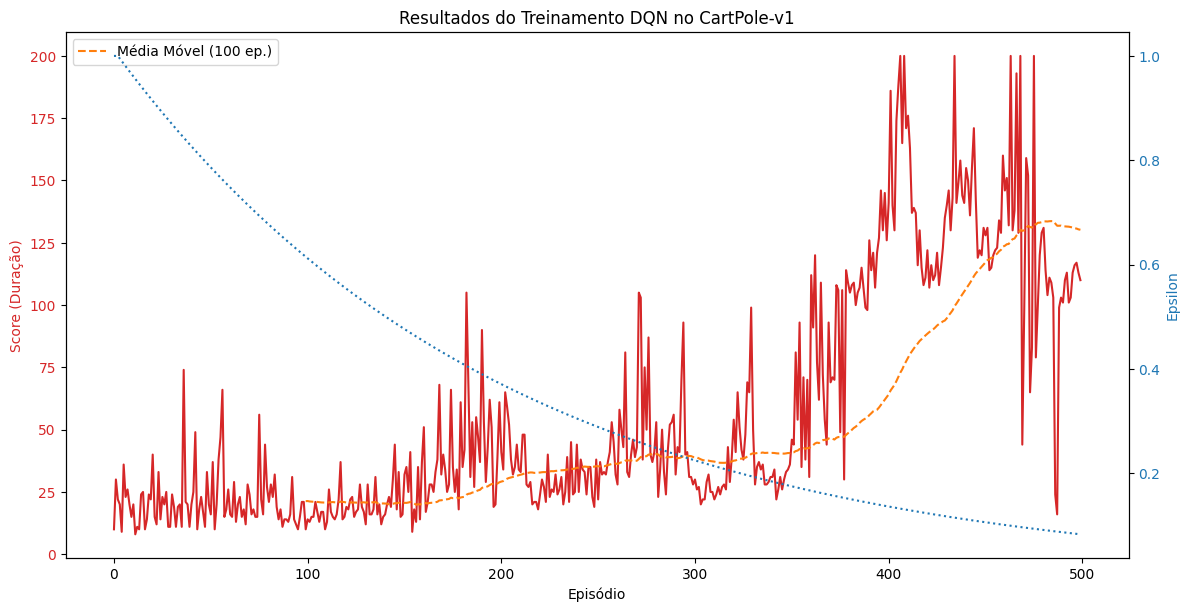


Iniciando Avaliação do Agente Treinado...
Avaliação - Episódio: 1/5, Score: 119
Avaliação - Episódio: 2/5, Score: 117
Avaliação - Episódio: 3/5, Score: 135
Avaliação - Episódio: 4/5, Score: 120
Avaliação - Episódio: 5/5, Score: 123


In [18]:
def evaluate_agent(agent, episodes=10):
    """Avalia o agente treinado e renderiza o ambiente."""
    env_eval = gym.make('CartPole-v1', render_mode="human") # Para visualização
    env_eval.reset(seed=RANDOM_SEED + 1) # Semente diferente para avaliação

    print("\nIniciando Avaliação do Agente Treinado...")
    for e in range(episodes):
        state, info = env_eval.reset()
        state = np.reshape(state, [1, agent.state_size])
        total_reward = 0
        for step in range(MAX_STEPS_PER_EPISODE):
            # Renderiza o ambiente. Em algumas configurações, isso acontece automaticamente.
            # Se não, descomente a linha abaixo.
            # env_eval.render() # Pode não ser necessário com render_mode="human" dependendo do backend

            action = np.argmax(agent.model.predict(state, verbose=0)[0]) # Ação gananciosa
            next_state, reward, terminated, truncated, _ = env_eval.step(action)
            done = terminated or truncated

            state = np.reshape(next_state, [1, agent.state_size])
            total_reward += reward
            if done:
                break
        print(f"Avaliação - Episódio: {e+1}/{episodes}, Score: {step+1}")
    env_eval.close()

if __name__ == "__main__":
    trained_agent, training_scores, training_epsilons = train_agent()
    plot_training_results(training_scores, training_epsilons)
    evaluate_agent(trained_agent, episodes=5)

# **Referências**

* SUTTON, R. S.; BARTO, A. G. **Reinforcement Learning: An Introduction**. 2. ed. Cambridge, MA: MIT Press, 2014/2015. Disponível em: https://web.stanford.edu/class/psych209/Readings/SuttonBartoIPRLBook2ndEd.pdf?spm=a2ty_o01.29997173.0.0.5c8dc9219U5Qlz&file=SuttonBartoIPRLBook2ndEd.pdf Acesso em: 01 de Maio de 2025.